In [8]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as f
import importlib
from load_data import load_dataset
import numpy as np

In [5]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA RTX PRO 6000 Blackwell Server Edition


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/sha/Documents/School/452/final_project/stl10/stl10/incomplete.19R0S3_1.0.0/stl10-test.tfrecor…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/sha/Documents/School/452/final_project/stl10/stl10/incomplete.19R0S3_1.0.0/stl10-unlabelled.t…

Dataset stl10 downloaded and prepared to /Users/sha/Documents/School/452/final_project/stl10/stl10/1.0.0. Subsequent calls will reuse this data.
x train shape: (5000, 96, 96, 3)
y train shape: (5000,)
x test shape: (8000, 96, 96, 3)
y test shape: (8000,)
Training dataset


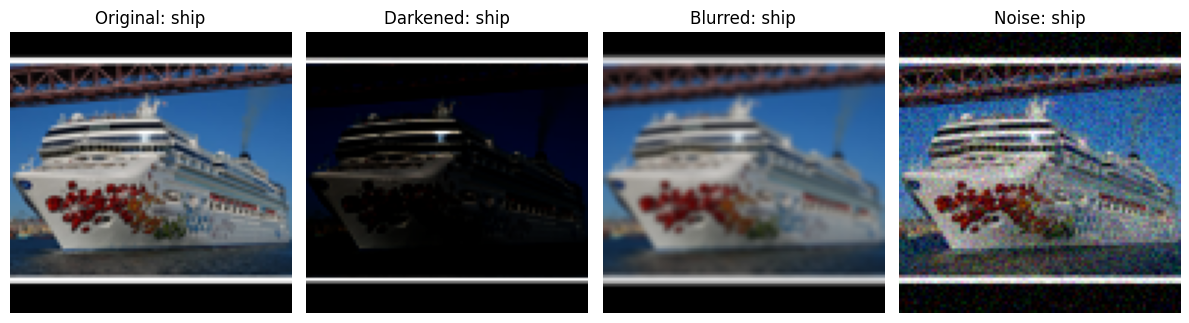

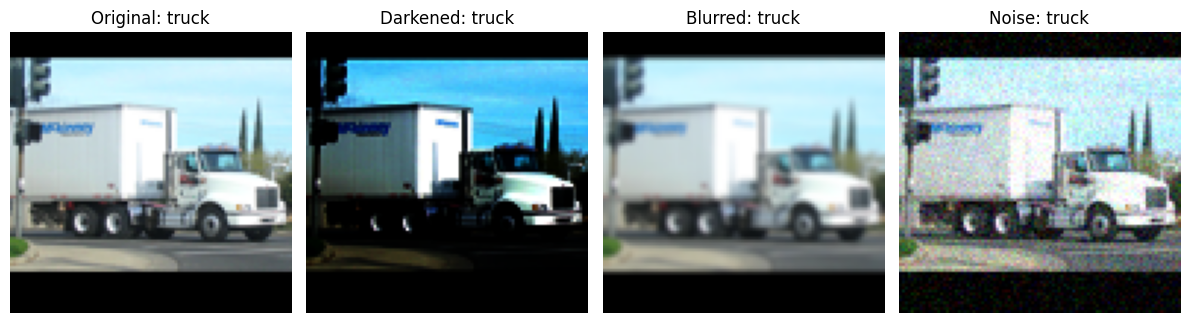

Test dataset


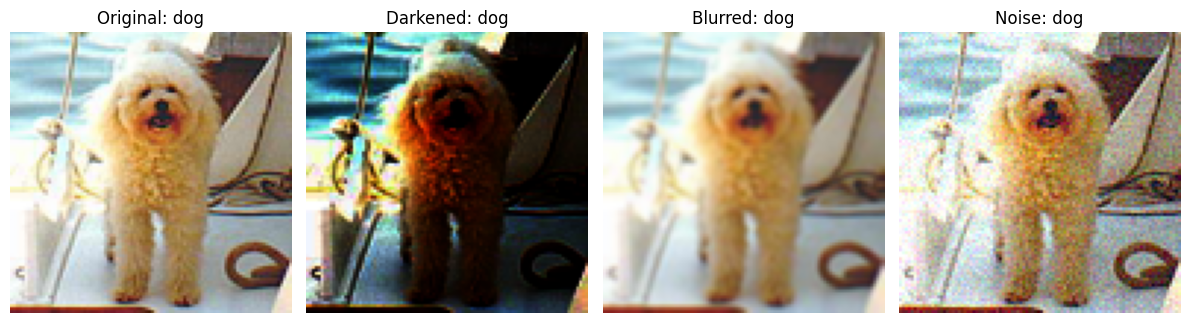

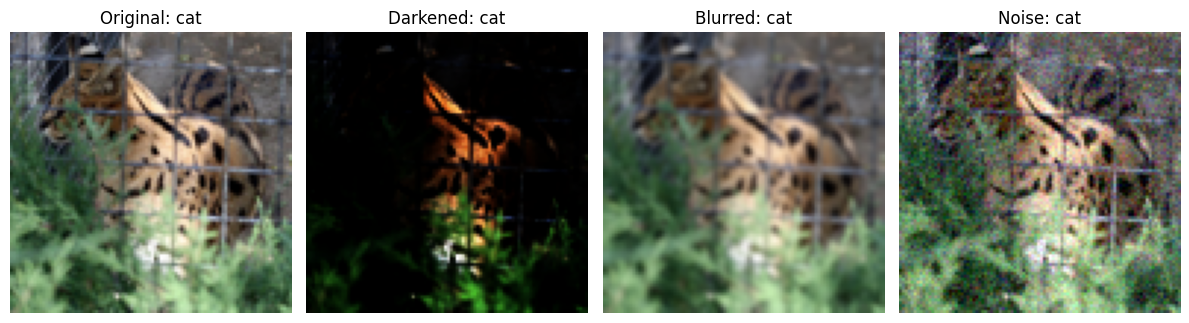

Numpy order: (n inputs, Height, Width, channels)
before permute: torch.Size([5000, 96, 96, 3])

pytorch order: (n inputs, channels, Height, Width)
x train after permute: torch.Size([5000, 3, 96, 96])
x train blur after permute: torch.Size([5000, 3, 96, 96])
x train noise after permute: torch.Size([5000, 3, 96, 96])
x train darken after permute: torch.Size([5000, 3, 96, 96])

pytorch order: (n inputs, channels, Height, Width)
x test after permute: torch.Size([8000, 3, 96, 96])
x test blur after permute: torch.Size([8000, 3, 96, 96])
x test noise after permute: torch.Size([8000, 3, 96, 96])
x test darken after permute: torch.Size([8000, 3, 96, 96])


In [6]:
x_train_tensor,x_train_blur_tensor,x_train_noise_tensor,x_train_darken_tensor,y_train_tensor,x_test_tensor,x_test_blur_tensor,x_test_noise_tensor,x_test_darken_tensor,y_test_tensor = load_dataset()

In [9]:
# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
class CorruptionImageDataset(Dataset):
    """Intialize our data set which includes the x train tensor, labels, and a list of
    our corrupted image: blur, noise, and darken"""
    def __init__(self, x,y,x_blur,x_noise,x_darken):
        self.x = x
        self.y = y
        self.corrupted_imgs = [x_blur,x_noise,x_darken]


    """How many samples exist in our train dataset"""
    def __len__(self):
        return len(self.x)

    def __getitem__(self,idx):
        clean_img = self.x[idx]
        label = self.y[idx]
        # https://numpy.org/doc/2.1/reference/random/generated/numpy.random.randint.html
        # Return random integers from low (inclusive) to high (exclusive)
        corrupt_set = np.random.randint(0, len(self.corrupted_imgs))
        corrupt_img = self.corrupted_imgs[corrupt_set][idx]

        return clean_img, corrupt_img, label


In [10]:
# train dataset and loader

train_dataset = CorruptionImageDataset(
    x_train_tensor,
    y_train_tensor,
    x_train_blur_tensor,
    x_train_noise_tensor,
    x_train_darken_tensor
)

# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [11]:
# https://discuss.pytorch.org/t/what-do-tensordataset-and-dataloader-do/107017/2
"""TensorDataset: Implements the __getitem__ and __len__ protocols
 for a set of tensors. It ensures your input data and targets stay aligned"""

# Test Loader Clean
test_clean_loader = DataLoader(TensorDataset(x_test_tensor,y_test_tensor),
batch_size=64,
shuffle=False)

# Test Loader Noise
test_noise_loader = DataLoader(TensorDataset(x_test_noise_tensor,y_test_tensor),
batch_size=64,
shuffle=False)

# Test Loader Blur
test_blur_loader = DataLoader(TensorDataset(x_test_blur_tensor,y_test_tensor),
batch_size=64,
shuffle=False)

# Test Loader Darken

test_darken_loader = DataLoader(TensorDataset(x_test_darken_tensor,y_test_tensor),
batch_size=64,
shuffle=False)

In [14]:
class ResBlock(nn.Module):
    # https://docs.pytorch.org/docs/2.11/generated/torch.nn.Sequential.html
    def __init__(self, in_channels, out_channels,stride=1):
        # https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/
        # add super
        super(ResBlock, self).__init__()
        # https://docs.pytorch.org/docs/2.11/generated/torch.nn.modules.conv.Conv2d.html
        self.conv1 = nn.Conv2d(in_channels,out_channels, kernel_size=3,stride=stride,padding=1)
        self.batch1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1)
        self.batch2 = nn.BatchNorm2d(out_channels)

        # https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/
        # we must guarantee that the shape of the output for F(x) and its skip connection (shortcut) output match in size
        self.shortcut = nn.Sequential()
        # https://medium.com/@hrbigelow/a-matrix-multiplication-view-of-convolutions-63ae2acfe43c
        # if stride increases (down samples) or our input doesn't match the out channels
        # then we have our skip connect match the shape of our output from F(x)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # https://www.geeksforgeeks.org/deep-learning/understanding-the-forward-function-output-in-pytorch/
    def forward(self,x):
        output = self.conv1(x)
        output = self.batch1(output)
        output = self.relu(output)
        output = self.conv2(output)
        output = self.batch2(output)
        output += self.shortcut(x)
        output = self.relu(output)

        return output

In [15]:
# https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/
class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        # output channels start at 64
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=64, kernel_size=3,stride=1,padding=1)
        self.batch1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.in_channels=64

        self.layer1 = self._make_layer(ResBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(ResBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(ResBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(ResBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)


    # Each layer contains 2 blocks and 4 convolutions
    # the shortcut is the optional step that is applied when there is a mismatch of shape
    # when stride /= 1
    def _make_layer(self,block, out_channels, num_blocks, stride):
        layers = []

        # create a residual block
        # ResBlock(nn.Module):
        # def __init__(self, in_channel, out_channel):
        layers.append(block(self.in_channels,out_channels,stride))
        # in layer 1 case; stride = 1; so out_channel == 64 thus in_channel == 64
        # in layer 2 case; stride = 2; so out_channel == 128, in_channel == 64

        # this matches our in_channels with the out_channels size
        self.in_channels = out_channels

        for i in range(1,num_blocks):
            layers.append(block(self.in_channels,out_channels,stride=1))

        """example
         layer 1 =
        [
            ResBlock(64, 64, stride=1),
            ResBlock(64, 64, stride=1)
        ]"""
        """ layer 2 =
        [
            ResBlock(64, 128, stride=2),
            ResBlock(128, 128, stride=1)
        ]"""
        """ layer 3 =
        [
            ResBlock(128, 256, stride=2),
            ResBlock(256, 256, stride=1)
        ]"""

        return nn.Sequential(*layers)


    def forward(self,x):
        output = self.conv1(x)
        output = self.batch1(output)
        output = self.relu(output)
        output = self.layer1(output)
        output = self.layer2(output)
        output = self.layer3(output)
        output = self.layer4(output)
        # https://medium.com/@YasinShafiei/residual-networks-resnets-with-implementation-from-scratch-713b7c11f612
        output = self.avgpool(output)
        output = output.view(output.shape[0], -1)
        output = self.fc(output)

        return output

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [69]:
model = ResNet18(num_classes=10)
model = model.to(device)

In [70]:
print(torch.cuda.is_available())
print(next(model.parameters()).device)

True
cuda:0


In [71]:

loss_fn = nn.CrossEntropyLoss()
# https://docs.pytorch.org/docs/2.11/generated/torch.nn.MSELoss.html
consistency_loss = nn.MSELoss()

# scalar
# adjust scalar score to determine how much to weigh the consistency loss
lmbda = 0.3

# https://www.codecademy.com/resources/docs/pytorch/optimizers/adam
# the dataset is small -- 5k so we use adam optimizer for faster convergence
# https://wandb.ai/wandb_fc/tips/reports/How-To-Calculate-Number-of-Model-Parameters-for-PyTorch-and-TensorFlow-Models--VmlldzoyMDYyNzIx#:~:text=PyTorch%20doesn't%20have%20a,to%20get%20the%20model%20parameters.&text=Let's%20quickly%20walk%20through%20this,might%20contain%20submodules%20as%20layers)
# get model parameters with model.parameters()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

train_losses = []
clean_losses = []
corrupt_losses = []
consis_losses = []


# https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html
# training loop
for epoch in range(EPOCHS):
    # https://yassin01.medium.com/understanding-the-difference-between-model-eval-and-model-train-in-pytorch-48e3002ee0a2
    model.train()
    epoch_loss = 0
    for i, data in enumerate(train_loader):
        clean, corrupted, label = data
        clean = clean.to(device)
        corrupted = corrupted.to(device)
        label = label.to(device)

        # gradients go to zero after every batch
        optimizer.zero_grad()

        clean_logits = model(clean)
        corrupt_logits = model(corrupted)

        # how accurate do our clean images predict the labels
        classif_clean_loss = loss_fn(clean_logits,label)
        # how accurat do our corrupt images predict the labels
        classif_corrupt_loss = loss_fn(corrupt_logits, label)

        # consistency loss function
        # how far off are the predicts between the corrupt and clean image
        # https://jamesmccaffreyblog.com/2024/06/11/pytorch-multi-class-classification-using-mseloss-instead-of-nllloss/
        # We use soft max instead of logits so our score values at capped at 1
        # this prevents large swings in the loss function
        clean_probs = f.softmax(clean_logits, dim = 1)
        corrupt_probs = f.softmax(corrupt_logits, dim =1)
        consis_loss = consistency_loss(clean_probs,corrupt_probs)

        total_loss = classif_clean_loss + classif_corrupt_loss + lmbda * consis_loss

        train_losses.append(total_loss.item())
        clean_losses.append(classif_clean_loss.item())
        corrupt_losses.append(classif_corrupt_loss.item())
        consis_losses.append(consis_loss.item())

        # https://www.geeksforgeeks.org/deep-learning/how-to-get-the-value-of-a-tensor-in-pytorch/
        epoch_loss += total_loss.item()


        total_loss.backward()
        optimizer.step()

    avg_epoch_loss = epoch_loss / len(train_loader)
    # https://www.w3schools.com/python/python_string_formatting.asp
    print(f"Epoch: {epoch+1}/{EPOCHS}  Loss: {avg_epoch_loss:.3f}")


Epoch: 1/10  Loss: 3.881
Epoch: 2/10  Loss: 3.515
Epoch: 3/10  Loss: 3.322
Epoch: 4/10  Loss: 3.169
Epoch: 5/10  Loss: 2.980
Epoch: 6/10  Loss: 2.829
Epoch: 7/10  Loss: 2.604
Epoch: 8/10  Loss: 2.496
Epoch: 9/10  Loss: 2.337
Epoch: 10/10  Loss: 2.227


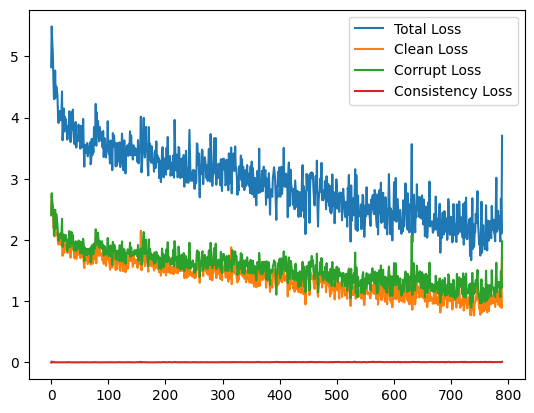

In [72]:
plt.plot(train_losses, label="Total Loss")
plt.plot(clean_losses, label="Clean Loss")
plt.plot(corrupt_losses, label="Corrupt Loss")
plt.plot(consis_losses, label="Consistency Loss")

plt.legend()
plt.show()

In [73]:
"""In this step we validate our model"""

# https://yassin01.medium.com/understanding-the-difference-between-model-eval-and-model-train-in-pytorch-48e3002ee0a2
# validate our model

def model_eval(model, loader):
    # validate our model
    model.eval()

    correct = 0
    total = 0
    confidence_list =[]


    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            y = y.to(device)
            output = model(x)

            # https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.softmax.html
            # give us the probability for each class in each x
            probs = f.softmax(output, dim=1)

            # https://docs.pytorch.org/docs/main/generated/torch.max.html
            # return the predictions for our softmax probabilities
            # Returns a namedtuple (values, indices) where values is the maximum value of each row of the input tensor
            # indices is the index location of each maximum value found (argmax)
            confidence, prediction = torch.max(probs, dim=1)

            for pred_idx, true_idx in zip(prediction,y):
                if pred_idx == true_idx:
                    correct += 1

            # the ground truth total
            total += len(y)
            confidence_list.extend(confidence.tolist())

    accuracy = correct / total
    avg_confidence_score = sum(confidence_list) / len(confidence_list)

    return accuracy, avg_confidence_score


In [74]:
clean_accuracy, clean_av_conf = model_eval(model,test_clean_loader)
noise_accuracy, noise_av_conf = model_eval(model,test_noise_loader)
blur_accuracy, blur_av_conf = model_eval(model,test_blur_loader)
darken_accuracy, darken_av_conf = model_eval(model,test_darken_loader)

print(f"Clean performance: accur: {clean_accuracy} avg conf: {clean_av_conf}")
print(f"Noise performance: accur: {noise_accuracy} avg conf: {noise_av_conf}")
print(f"Blur performance: accur: {blur_accuracy} avg conf: {blur_av_conf}")
print(f"Darken performance: accur: {darken_accuracy} avg conf: {darken_av_conf}")

Clean performance: accur: 0.585625 avg conf: 0.6030092959478498
Noise performance: accur: 0.57375 avg conf: 0.5812250975277274
Blur performance: accur: 0.552375 avg conf: 0.6095240909028798
Darken performance: accur: 0.41625 avg conf: 0.4860487016979605


In [115]:
import random
def display_images(x,y,x_darken,x_blur,x_noise,model):
    model.eval()
    for i in range(2):
        plt.figure(figsize=(14,4))
       # https://cs.stanford.edu/~acoates/stl10/
        # class labels
        labels = {0: "airplane",1: "bird",2: "car", 3: "cat", 4: "deer", 5: "dog", 6: "horse",
        7: "monkey", 8: "ship", 9: "truck"}
        # get index for the length of our test dataset
        idx = random.randint(0,len(x)-1)
        true_label = labels[y[idx].item()]

        # create image tuple to iterate through for display
        # imgs contains the name of our dataset and a random index
        # used to grab the image inside of the dataset
        imgs = [("Clean", x[idx]),
            ("Darken", x_darken[idx]),
            ("Blur", x_blur[idx]),
            ("Noise", x_noise[idx])]

        for i, (name, img) in enumerate(imgs):

          # call our model to get the prediction label and confidence score
          with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            # just as above get our confidence socre and prediction label
            probs = f.softmax(output, dim=1)
            confidence, prediction = torch.max(probs, dim=1)

          # prediction is numerical so we need to pass as key to get the
          # string value from our labels dictionary
          pred_label = labels[prediction.item()]
          conf_score = confidence.item()

          # Convert from (Channel, Height, Width)
          # to (Height, Width, Channel) for matlib.pyplot format
          plot_img = img.permute(1, 2, 0)


          plt.subplot(1,4,i+1)
          plt.imshow(plot_img)
          plt.title(f"{name}\n{pred_label} {conf_score:.2f}")
          plt.axis("off")

        plt.suptitle(f"True: {true_label}")
        plt.tight_layout()
        plt.show()

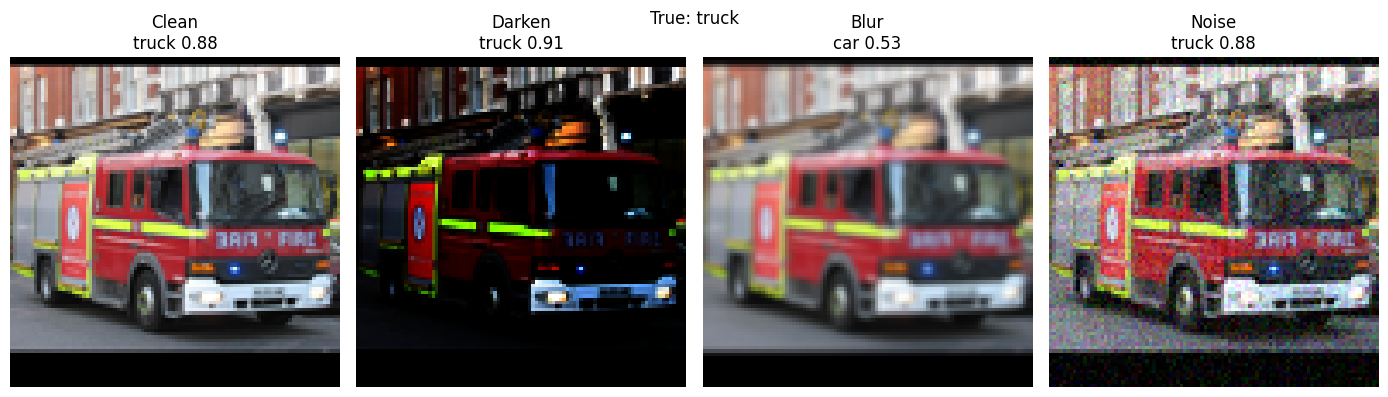

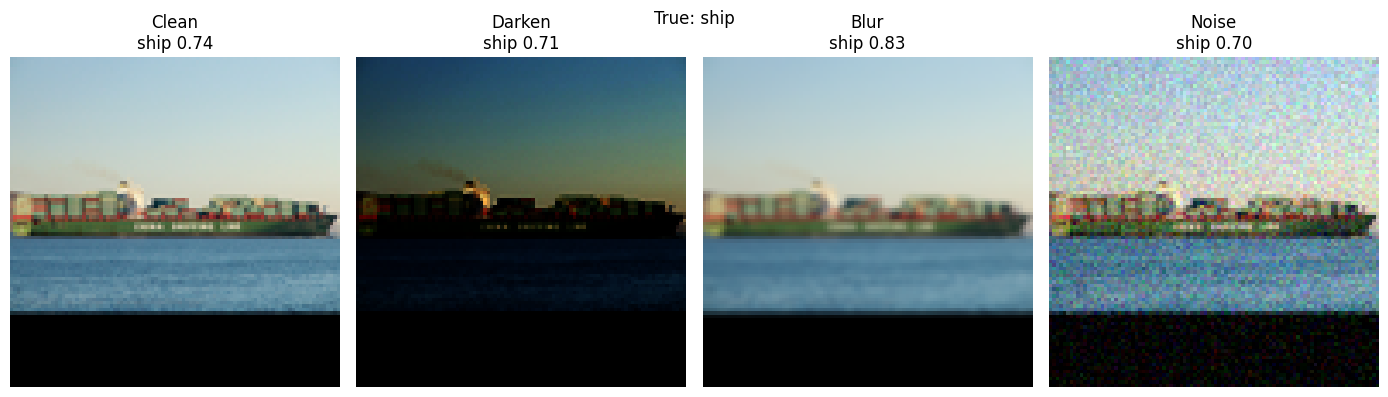

In [131]:
display_images(x_test_tensor,y_test_tensor,x_test_darken_tensor,x_test_blur_tensor,x_test_noise_tensor,model)